<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Screen 1,000 Peptides Before Lunch

Multi-stage pipeline to screen a peptide library for thermal stability and solubility.

<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://www.svgrepo.com/show/354202/postman-icon.svg" style="height: 15px; float: left; padding-right: 10px;"><a href="https://api.biolm.ai/">  <h5 style="margin: 0;"><b>Postman API Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/Python-logo-notext.svg/1869px-Python-logo-notext.svg.png" style="height: 15px; float: left; padding-right: 10px;"><a href="https://docs.biolm.ai/en/latest/index.html"><h5 style="margin: 0;"><b>Python SDK Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
    </tr>
</table>

<br>

---

**What you'll learn:**
- Defining a multi-stage pipeline with parallel predictions
- Filtering by melting temperature and solubility
- Exploring results with `summary()`, `stats()`, and SQL queries

**Requirements:**
```
pip install biolmai matplotlib
export BIOLMAI_TOKEN=your-token-here
```

## Setup

In [1]:
import os
from biolmai.pipeline import (
    DataPipeline, DuckDBDataStore,
    ThresholdFilter, RankingFilter,
    ValidAminoAcidFilter, EmbeddingSpec,
    DiversitySamplingFilter,
)

TOKEN = os.environ.get("BIOLMAI_TOKEN", "")
if not TOKEN:
    raise EnvironmentError(
        "Set BIOLMAI_TOKEN before running.\n"
        "Get one at https://biolm.ai/ui/accounts/user-api-tokens/"
    )

## Peptide library

30 antimicrobial peptides of varying length, charge, and hydrophobicity.

In [2]:
MY_PEPTIDES = [
    # Magainins / frog-derived
    "GIGKFLHSAKKFGKAFVGEIMNS",
    "GIGKFLHSAGKFGKAFVGEIMKS",
    "GLFDIIKKIAESF",
    "GLFDIVKKVVGALGSL",
    "FLPLILRKIVTAL",
    # Human defensins / cathelicidins
    "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES",
    "RLFDKIRQVIRKF",
    "KWKLFKKIPKFLHLAKKF",
    # Insect-derived
    "GIGAVLKVLTTGLPALISWIKRKRQQ",
    "VDKGSYLPRPTPPRPIYNRN",
    # Synthetic / designed
    "KLAKLAKKLAKLAK",
    "LKLLKKLLKLLKKL",
    "RRWWRRWWRR",
    "KWKWKWKWKW",
    "GIKKFLGSIWKFIKAFVKEIMN",
    # Short peptides
    "RRWQWR",
    "RWRWRW",
    "FKRIVQRIKDFL",
    "KFLKKAKKFGK",
    "GIGKFLHSAK",
    "KWKLFKKI",
    "RLFDKIRQ",
    # Longer peptides
    "GLFDIIKKIAESFLPKV",
    "GIGKFLHSAKKFGKAFV",
    "KWKLFKKIPKFLHLAK",
]
print(f"{len(MY_PEPTIDES)} peptides, length range: {min(len(s) for s in MY_PEPTIDES)}–{max(len(s) for s in MY_PEPTIDES)} aa")

25 peptides, length range: 6–37 aa


## Build and run the pipeline

The dependency graph:
```
validate
   ├── predict_tm   ─┐
   └── predict_sol  ─┴── filter_tm >= 40°C ── rank top 15 by solubility
```
Both prediction stages run in **parallel** because they share the same dependency.

In [3]:
pipeline = DataPipeline(sequences=MY_PEPTIDES, verbose=True)

pipeline.add_filter(ValidAminoAcidFilter(), stage_name="validate")

pipeline.add_prediction(
    "temberture-regression", extractions="prediction",
    columns="melting_temperature", stage_name="predict_tm",
    depends_on=["validate"],
)
pipeline.add_prediction(
    "biolmsol", extractions="solubility_score",
    columns="solubility", stage_name="predict_sol",
    depends_on=["validate"],
)

pipeline.add_filter(ThresholdFilter("melting_temperature", min_value=40.0), stage_name="filter_tm")
pipeline.add_filter(RankingFilter("solubility", n=15, ascending=False), stage_name="top15")

pipeline.run()

Added stage: FilterStage('validate')
Added stage: PredictionStage('predict_tm', depends_on=['validate'])
Added stage: PredictionStage('predict_sol', depends_on=['validate'])
Added stage: FilterStage('filter_tm', depends_on=['predict_sol'])
Added stage: FilterStage('top15', depends_on=['filter_tm'])

############################################################
# Pipeline: DataPipeline
# Run ID: 20260616_113817_054f9870
# Initial sequences: 25
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: validate
  Level 2: predict_tm, predict_sol (parallel)
  Level 3: filter_tm
  Level 4: top15

Stage: validate
Input: 25 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/25
  Remaining: 25

StageResult(validate: in=25, out=25, cached=0, computed=0, filtered=0, time=0.0s)

Executing 2 stages in parallel...

Stage: predict_tm
Input: 25 sequences
Depends on: validate
  Cached: 0/25



Stage: predict_sol
Input: 25 sequences
Depends on: validate
  Cached: 0/25
  To compute: 25
  Calling biolmsol.predict...


  Completed: 25 sequences in 1 batches (max 5 concurrent)

StageResult(predict_sol: in=25, out=25, cached=0, computed=25, filtered=0, time=4.3s)


Stage 'top15' received empty WorkingSet — skipping


  Completed: 25 sequences in 1 batches (max 5 concurrent)

StageResult(predict_tm: in=25, out=0, cached=0, computed=25, filtered=25, time=18.4s)

Stage: filter_tm
Input: 25 sequences
Depends on: predict_sol
  Applying filter: ThresholdFilter(column='melting_temperature', min=40.0)
  Filtered out: 25/25
  Remaining: 0

StageResult(filter_tm: in=25, out=0, cached=0, computed=0, filtered=25, time=0.0s)

############################################################
# Pipeline completed in 18.5s
# Final sequences: 0
############################################################



{'validate': StageResult(validate: in=25, out=25, cached=0, computed=0, filtered=0, time=0.0s),
 'predict_tm': StageResult(predict_tm: in=25, out=0, cached=0, computed=25, filtered=25, time=18.4s),
 'predict_sol': StageResult(predict_sol: in=25, out=25, cached=0, computed=25, filtered=0, time=4.3s),
 'filter_tm': StageResult(filter_tm: in=25, out=0, cached=0, computed=0, filtered=25, time=0.0s),
 'top15': StageResult(top15: in=0, out=0, cached=0, computed=0, filtered=0, time=0.0s)}

## Explore results

In [4]:
pipeline.summary()

,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,25,25,0,0,0,0.0
1,predict_tm,25,0,25,0,25,18.4
2,predict_sol,25,25,0,0,25,4.3
3,filter_tm,25,0,25,0,0,0.0
4,top15,0,0,0,0,0,0.0


In [5]:
pipeline.stats()

,stage_name,status,input_count,output_count,completed_at
0,validate,completed,25,25,2026-06-16 11:38:17.778323
1,predict_sol,completed,25,25,2026-06-16 11:38:22.286991
2,predict_tm,completed,25,0,2026-06-16 11:38:36.217941
3,filter_tm,completed,25,0,2026-06-16 11:38:36.227741
4,top15,completed,0,0,2026-06-16 11:38:36.231844


In [6]:
# Top 10 sequences by melting temperature
pipeline.query("""
    SELECT s.sequence,
           MAX(CASE WHEN p.prediction_type = 'melting_temperature' THEN p.value END) AS tm,
           MAX(CASE WHEN p.prediction_type = 'solubility' THEN p.value END) AS solubility
    FROM sequences s
    JOIN predictions p ON s.sequence_id = p.sequence_id
    GROUP BY s.sequence
    ORDER BY tm DESC
    LIMIT 10
""")

,sequence,tm,solubility
0,FLPLILRKIVTAL,NaN,0.179467
1,RRWWRRWWRR,NaN,1.276301
2,FKRIVQRIKDFL,NaN,1.318316
3,RLFDKIRQ,NaN,1.577740
4,KLAKLAKKLAKLAK,NaN,2.326550
5,RWRWRW,NaN,0.667661
6,KWKLFKKIPKFLHLAK,NaN,1.308439
7,KWKWKWKWKW,NaN,0.867894
8,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,NaN,1.391619
9,KFLKKAKKFGK,NaN,2.850865


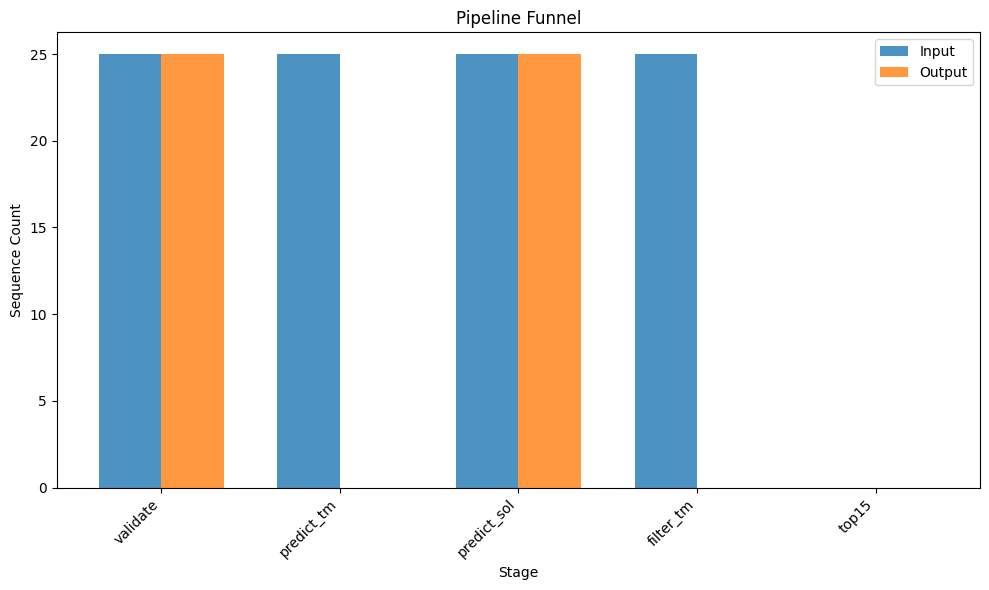

In [7]:
pipeline.plot("funnel")

## Next Steps

Check out additional tutorials at [jupyter.biolm.ai](https://jupyter.biolm.ai),
or head over to our [BioLM Documentation](https://docs.biolm.ai) to explore
additional models and functionality.

#### See more use-cases and APIs on your [BioLM Console Catalog](https://biolm.ai/console/catalog/).
<br>

##### BioLM hosts deep learning models and runs inference at scale. You do the science.
<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/enzyme_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Enzyme Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/antibody_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Antibody Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/biosecurity_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Biosecurity
        </td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/single_cell_genomics_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Single-Cell Genomics
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/dna_seq_modeling_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> DNA Sequence Modelling
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/finetuning_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Finetuning
        </td>
    </tr>
</table>

#### [**Contact us**](https://biolm.ai/ui/contact-us/) to learn more.